# Volatility Smile & Surface

This notebook analyses real option-chain data and extracts implied volatility patterns across strikes and maturities. The analysis starts by cleaning market data from Yahoo Finance and then uses the cleaned data to compute and visualize volatility smiles and volatility surfaces.

## Preparations & Exploratory Analysis

SPY is used as the underlying because it tracks the S&P 500 and has highly liquid option markets, making it suitable for analysing implied volatility patterns.

The downloaded option chain is inspected to understand its structure and available variables.

In [1]:
import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata
from matplotlib.ticker import PercentFormatter

from quant_finance.options.implied_volatility import implied_volatility

In [2]:
ticker_symbol = "SPY"
ticker = yf.Ticker(ticker_symbol)

expirations = ticker.options

target_days = 45
expiry_dates = pd.to_datetime(expirations)
target_date = pd.Timestamp.today().normalize() + pd.Timedelta(days=target_days)

# Select the available option expiry closest to the 45-day target maturity
closest_index = abs(expiry_dates - target_date).argmin()
expiry = expirations[closest_index]

print("Selected expiry:", expiry)

chain = ticker.option_chain(expiry)
calls = chain.calls
puts = chain.puts

Selected expiry: 2026-08-21


In [3]:
calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260821C00360000,2026-07-09 19:49:00+00:00,360.0,393.67,395.46,397.74,0.0,0.0,62.0,187,1.107915,True,REGULAR,USD
1,SPY260821C00365000,2026-07-09 19:49:00+00:00,365.0,388.72,390.38,393.19,0.0,0.0,62.0,118,1.108037,True,REGULAR,USD
2,SPY260821C00370000,2026-04-17 14:32:05+00:00,370.0,343.98,369.32,372.12,0.0,0.0,3.0,3,0.000010,True,REGULAR,USD
3,SPY260821C00375000,2026-04-07 19:20:29+00:00,375.0,288.49,363.80,367.00,0.0,0.0,NaN,0,0.000010,True,REGULAR,USD
4,SPY260821C00395000,2026-06-30 16:50:04+00:00,395.0,354.43,360.56,363.36,0.0,0.0,42.0,42,1.014775,True,REGULAR,USD


In [4]:
puts.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260821P00360000,2026-07-10 19:54:04+00:00,360.0,0.03,0.03,0.04,-0.01,-25.000000,11601.0,31008.0,0.714847,False,REGULAR,USD
1,SPY260821P00365000,2026-07-10 17:47:00+00:00,365.0,0.04,0.03,0.04,-0.01,-20.000004,397.0,7340.0,0.703128,False,REGULAR,USD
2,SPY260821P00370000,2026-07-10 19:15:18+00:00,370.0,0.04,0.03,0.04,-0.01,-20.000004,318.0,13243.0,0.691409,False,REGULAR,USD
3,SPY260821P00375000,2026-07-10 20:11:03+00:00,375.0,0.04,0.03,0.04,-0.03,-42.857143,425.0,5148.0,0.679691,False,REGULAR,USD
4,SPY260821P00380000,2026-07-10 17:42:42+00:00,380.0,0.05,0.04,0.05,-0.02,-28.571426,152.0,9116.0,0.679691,False,REGULAR,USD


In [5]:
calls.columns

Index(['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask',
       'change', 'percentChange', 'volume', 'openInterest',
       'impliedVolatility', 'inTheMoney', 'contractSize', 'currency'],
      dtype='object')

In [6]:
calls.describe()

,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,234.000000,238.000000,238.000000
mean,707.500000,75.069874,74.380924,75.953487,1.184706,5.035021,302.517094,2130.680672,0.296605
std,130.836928,93.235714,94.268812,95.102283,2.515078,10.593969,717.995506,4231.808719,0.214532
min,360.000000,0.010000,0.000000,0.000000,-0.759998,-50.000000,1.000000,0.000000,0.000010
25%,658.250000,4.832500,3.715000,3.745000,0.000000,0.000000,2.000000,28.000000,0.145894
50%,717.500000,43.050000,39.945000,42.725000,0.000000,0.000000,6.500000,544.000000,0.233597
75%,776.750000,89.065000,95.695000,98.480000,1.340000,10.368169,127.500000,2015.000000,0.349967
max,1000.000000,393.670000,395.460000,397.740000,17.809998,100.000000,4826.000000,25876.000000,1.108037


The summary statistics indicate that the raw data contains low-liquidity and potentially unreliable observations. Therefore, data-cleaning is required.

## Data Preparation & Cleaning

Before calculating implied volatilities, additional pricing and liquidity variables are created and the option data is cleaned by removing observations with unreliable prices and low liquidity.

In [7]:
calls_work = calls.copy()

calls_work["option_type"] = "call"
calls_work["expiration"] = expiry
calls_work["mid_price"] = (calls_work["bid"] + calls_work["ask"]) / 2
calls_work["bid_ask_spread"] = calls_work["ask"] - calls_work["bid"]
calls_work["relative_spread"] = calls_work["bid_ask_spread"] / calls_work["mid_price"]

In [8]:
calls_filtered = calls_work[
    (calls_work["bid"] > 0)
    & (calls_work["ask"] > 0)
    & (calls_work["ask"] >= calls_work["bid"])
    & (calls_work["mid_price"] > 0)
    & (calls_work["relative_spread"] < 0.2)
    & (calls_work["openInterest"] > 0)
].copy()

In [9]:
spot_price = ticker.history(period="1d")["Close"].iloc[-1]

In [10]:
calls_filtered["moneyness"] = calls_filtered["strike"] / spot_price

expiry_date = datetime.datetime.strptime(expiry, "%Y-%m-%d").date()
valuation_date = calls_filtered["lastTradeDate"].max().date()

T = (expiry_date - valuation_date).days / 365

calls_filtered["T"] = T

In [11]:
calls_smile = calls_filtered[
    (calls_filtered["moneyness"] >= 0.8)
    & (calls_filtered["moneyness"] <= 1.2)
    & (calls_filtered["impliedVolatility"] > 0.01)
    & (calls_filtered["impliedVolatility"] < 2.0)
].copy()

## Implied Volatility

To calculate implied volatility, the Black-Scholes model requires assumptions for the risk-free interest rate \(r\) and the continuous dividend yield \(q\). Here, constant values are used as reasonable approximations for the selected SPY option maturities.

The implied volatility is then obtained numerically by solving for the volatility parameter that reproduces the observed option mid-price.

In [12]:
# Approximate risk-free rate and SPY dividend yield
r = 0.038
q = 0.011

In [13]:
def compute_iv_row(row, spot_price, r, q):
    try:
        return implied_volatility(
            C=row["mid_price"],
            S=spot_price,
            K=row["strike"],
            r=r,
            T=row["T"],
            q=q,
            option_type=row["option_type"],
            method="newton",
        )
    except (ValueError, RuntimeError):
        return np.nan

### Volatility Smile

A volatility smile describes how implied volatility varies across option strikes or moneyness levels for a fixed maturity. In equity markets, the pattern is often asymmetric, with higher implied volatilities for lower strikes, resulting in a volatility skew or smirk rather than a symmetric smile.

The following analysis compares Yahoo Finance implied volatilities with implied volatilities calculated using the implemented Black-Scholes inversion routine.

In [14]:
own_ivs = []

for _, row in calls_smile.iterrows():
    iv = compute_iv_row(row, spot_price, r, q)
    own_ivs.append(iv)

calls_smile["own_implied_volatility"] = own_ivs

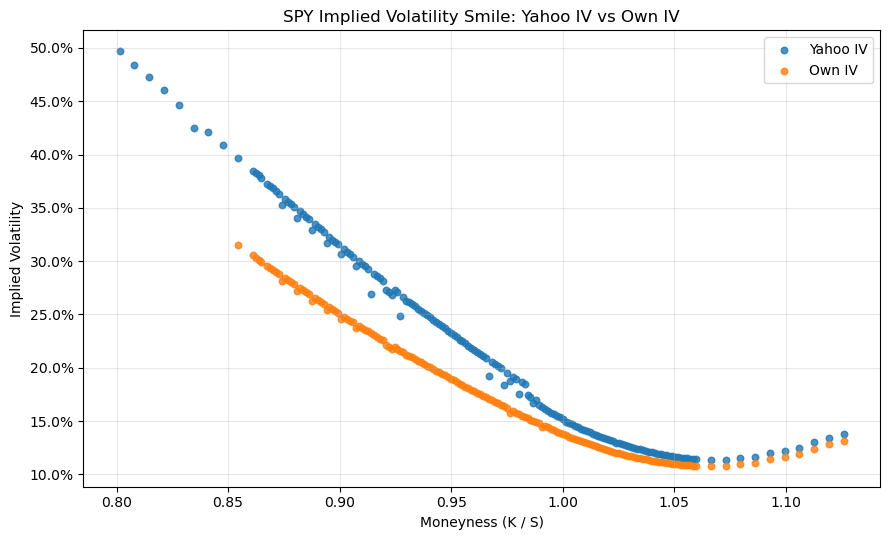

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(
    x=calls_smile["moneyness"],
    y=calls_smile["impliedVolatility"],
    label="Yahoo IV",
    s=22,
    alpha=0.8,
)

ax.scatter(
    x=calls_smile["moneyness"],
    y=calls_smile["own_implied_volatility"],
    label="Own IV",
    s=22,
    alpha=0.8,
)

ax.set_xlabel("Moneyness (K / S)")
ax.set_ylabel("Implied Volatility")
ax.set_title("SPY Implied Volatility Smile: Yahoo IV vs Own IV")

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The calculated implied volatilities follow the same overall pattern as the Yahoo Finance values. Differences are more visible for deeper in-the-money options, while the two estimates are generally closer around the at-the-money region.

The observed shape is asymmetric rather than a symmetric smile, which is typical for equity index options and reflects the market's higher pricing of downside risk.

### Volatility Surface

A volatility surface extends the volatility smile across multiple maturities and shows how implied volatility varies jointly with moneyness and time to maturity.

The following analysis selects option expiries close to predefined target maturities and calculates implied volatilities for both call and put options.

In [16]:
def prepare_iv_data(expiry, ticker, spot_price, r, q, option_type):

    # Download option chain
    chain = ticker.option_chain(expiry)

    if option_type == "call":
        options = chain.calls
    elif option_type == "put":
        options = chain.puts
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    # Create working columns
    options_work = options.copy()

    options_work["option_type"] = option_type
    options_work["expiration"] = expiry
    options_work["mid_price"] = (
        options_work["bid"] + options_work["ask"]
    ) / 2

    options_work["bid_ask_spread"] = (
        options_work["ask"] - options_work["bid"]
    )

    options_work["relative_spread"] = (
        options_work["bid_ask_spread"] / options_work["mid_price"]
    )

    # Clean data
    options_filtered = options_work[
        (options_work["bid"] > 0)
        & (options_work["ask"] > 0)
        & (options_work["ask"] >= options_work["bid"])
        & (options_work["mid_price"] > 0)
        & (options_work["relative_spread"] < 0.2)
        & (options_work["openInterest"] > 0)
    ].copy()

    # Calculate moneyness
    options_filtered["moneyness"] = (
        options_filtered["strike"] / spot_price
    )

    # Calculate time to maturity
    expiry_date = datetime.datetime.strptime(
        expiry, "%Y-%m-%d"
    ).date()

    valuation_date = options_filtered[
        "lastTradeDate"
    ].max().date()

    T = (expiry_date - valuation_date).days / 365

    options_filtered["T"] = T

    # Restrict moneyness
    options_smile = options_filtered[
        (options_filtered["moneyness"] >= 0.8)
        & (options_filtered["moneyness"] <= 1.2)
        & (options_filtered["impliedVolatility"] > 0.01)
        & (options_filtered["impliedVolatility"] < 2.0)
    ].copy()

    # Calculate own implied volatility
    own_ivs = []

    for _, row in options_smile.iterrows():
        iv = compute_iv_row(row, spot_price, r, q)
        own_ivs.append(iv)

    options_smile["own_implied_volatility"] = own_ivs

    return options_smile

In [17]:
target_days = [7, 14, 21, 30, 45, 60, 75, 90, 120, 150, 180, 240, 300, 360]

expiry_dates = pd.to_datetime(expirations)
selected_expiries = []

for days in target_days:
    target_date = pd.Timestamp.today().normalize() + pd.Timedelta(days=days)
    closest_index = abs(expiry_dates - target_date).argmin()
    expiry = expirations[closest_index]

    if expiry not in selected_expiries:
        selected_expiries.append(expiry)

print("Selected expiries:", selected_expiries)

Selected expiries: ['2026-07-20', '2026-07-24', '2026-07-31', '2026-08-14', '2026-08-21', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-30', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-30']


#### Volatility Surface for Call Options

The call-option surface is constructed from the calculated implied volatilities across the selected maturities and moneyness levels.

In [18]:
call_surface_data = []

for expiry in selected_expiries:
    expiry_data = prepare_iv_data(
        expiry=expiry,
        ticker=ticker,
        spot_price=spot_price,
        r=r,
        q=q,
        option_type="call",
    )

    call_surface_data.append(expiry_data)

In [19]:
calls_surface = pd.concat(call_surface_data, ignore_index=True)

calls_surface_clean = calls_surface.dropna(
    subset=["own_implied_volatility"]
).copy()

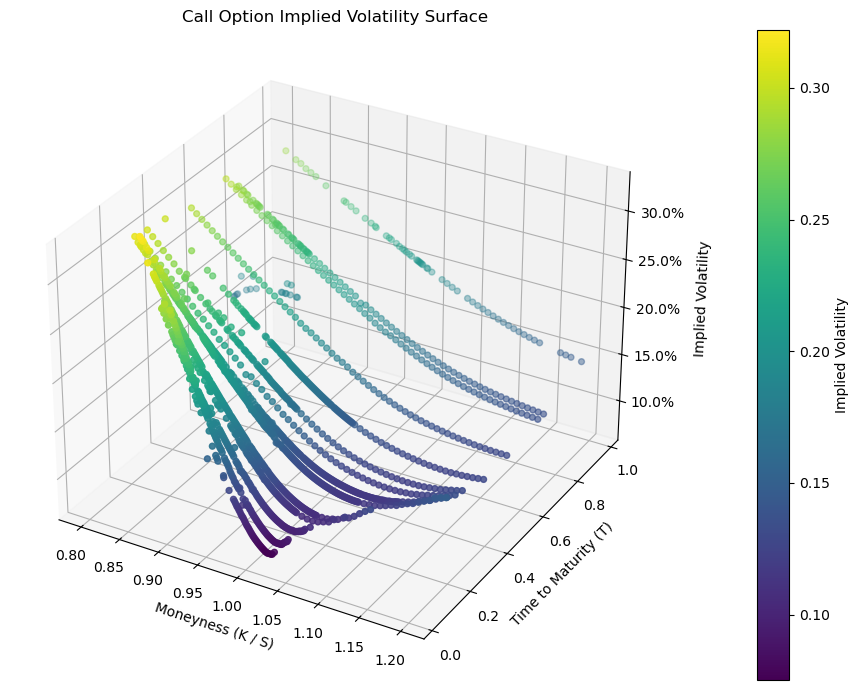

In [20]:

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    calls_surface_clean["moneyness"],
    calls_surface_clean["T"],
    calls_surface_clean["own_implied_volatility"],
    c=calls_surface_clean["own_implied_volatility"],
    cmap="viridis",
    s=18,
)

ax.set_xlabel("Moneyness (K / S)")
ax.set_ylabel("Time to Maturity (T)")
ax.set_zlabel("Implied Volatility", labelpad=14)

ax.set_title("Call Option Implied Volatility Surface")

ax.zaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="z", pad=7)

cbar = fig.colorbar(scatter, pad=0.1)
cbar.set_label("Implied Volatility")

plt.tight_layout()
plt.show()

In [21]:
# Prepare data for interpolation
x = calls_surface_clean["moneyness"].to_numpy()
y = calls_surface_clean["T"].to_numpy()
z = calls_surface_clean["own_implied_volatility"].to_numpy()

# Create regular grid
x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)

X, Y = np.meshgrid(x_grid, y_grid)

# Interpolate implied volatility onto the grid
Z = griddata(
    (x, y),
    z,
    (X, Y),
    method="linear",
)

# Create interactive 3D volatility surface
fig_plotly = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale="Viridis",
            colorbar=dict(
                title="Implied Volatility"
            ),
        )
    ]
)

fig_plotly.update_layout(
    title="Call Option Implied Volatility Surface",

    scene=dict(
        xaxis_title="Moneyness (K / S)",
        yaxis_title="Time to Maturity (T)",
        zaxis_title="Implied Volatility",

        dragmode="turntable",

        camera=dict(
            eye=dict(
                x=0.0,
                y=-2.5,
                z=0.5,
            ),
            up=dict(
                x=0,
                y=0,
                z=1,
            ),
        ),
    ),

    width=1000,
    height=750,
)

fig_plotly.show()

The call-option volatility surface shows a clear dependence of implied volatility on both moneyness and maturity. Lower-strike options generally exhibit higher implied volatilities, reflecting the typical downside skew observed in equity index option markets.

Some implied volatility calculations fail for deep in-the-money options because the observed market mid-price can fall outside the theoretical Black-Scholes price bounds under the chosen model inputs. These observations are retained as missing values and excluded from the visualization.

#### Volatility Surface for Put Options

The same procedure is applied to put options in order to analyse the corresponding volatility structure across moneyness and maturity.

In [22]:
put_surface_data = []

for expiry in selected_expiries:
    expiry_data = prepare_iv_data(
        expiry=expiry,
        ticker=ticker,
        spot_price=spot_price,
        r=r,
        q=q,
        option_type="put",
    )

    put_surface_data.append(expiry_data)

In [23]:
puts_surface = pd.concat(
    put_surface_data,
    ignore_index=True,
)

In [24]:
puts_surface_clean = puts_surface.dropna(
    subset=["own_implied_volatility"]
).copy()

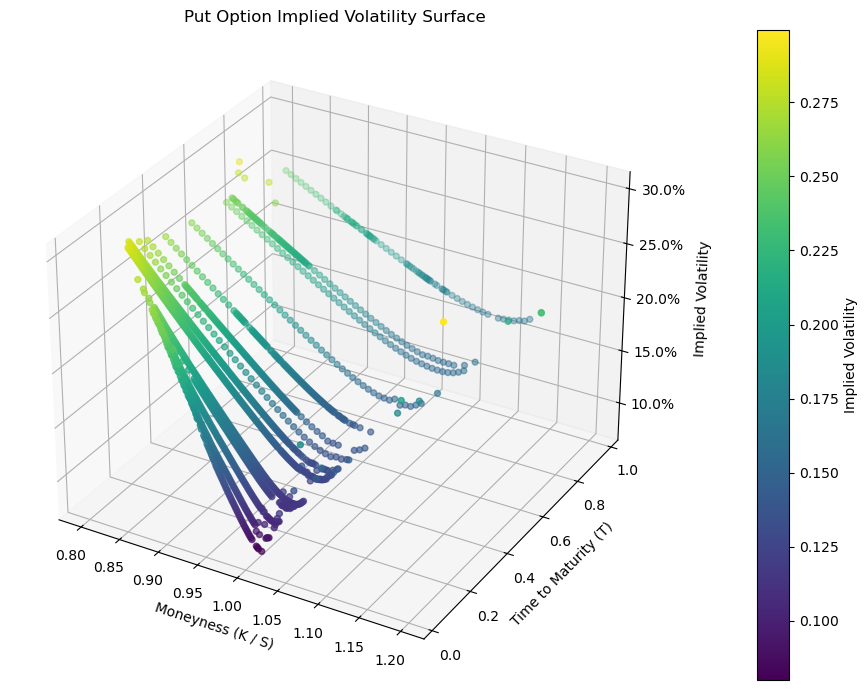

In [25]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    puts_surface_clean["moneyness"],
    puts_surface_clean["T"],
    puts_surface_clean["own_implied_volatility"],
    c=puts_surface_clean["own_implied_volatility"],
    cmap="viridis",
    s=18,
)

ax.set_xlabel("Moneyness (K / S)")
ax.set_ylabel("Time to Maturity (T)")
ax.set_zlabel("Implied Volatility", labelpad=14)

ax.set_title("Put Option Implied Volatility Surface")

ax.zaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="z", pad=7)

cbar = fig.colorbar(scatter, pad=0.1)
cbar.set_label("Implied Volatility")

plt.tight_layout()
plt.show()

The put-option surface shows a similar overall volatility structure across moneyness and maturity. Differences between call and put implied volatilities can arise from market microstructure effects, asynchronous quotes, bid-ask spreads, model assumptions, and the American exercise feature of SPY options.

## Limitations

The analysis relies on several simplifying assumptions and market-data limitations:

- The risk-free rate and dividend yield are assumed to be constant across strikes and maturities.
- Option and underlying prices may not be perfectly synchronized, which can affect implied volatility estimates.
- Yahoo Finance may use different pricing inputs, conventions, or methodology when calculating implied volatility.
- SPY options are American-style, while the implemented Black-Scholes model assumes European exercise.
- Short-dated options can produce unstable implied volatility estimates because small price differences may lead to larger changes in implied volatility, particularly when vega is low.
- Some deep in-the-money options cannot be inverted because their observed market mid-price falls outside the theoretical Black-Scholes price bounds under the chosen assumptions.
- The interactive three-dimensional surface is created by linearly interpolating between discrete option observations and therefore represents a visual approximation.

Despite these limitations, the analysis successfully reproduces the main volatility patterns observed in the market and demonstrates the construction of volatility smiles and surfaces from real option data.